In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

## 字体设置（解决中文乱码）
rcParams['font.sans-serif'] = 'SimHei'
rcParams['axes.unicode_minus'] = False
import seaborn as sns

In [58]:
df=pd.read_csv('C:/Users\Administrator\Desktop/douyin.csv')
df.head(20)

,spu_id,spu_name,user_id,brand_name,shop_id,shop_name,c1_id,c1_name,c2_id,c2_name,c3_id,c3_name,gmv,unit_sold,brand_clean
0,3445769446910786789,浒城古娘休闲阔腿裤-SA1945,NaN,浒城古娘 (hcgn),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9995.000000,5,NaN
1,3413099447008239629,蜜丝婷Mistine小蓝帽防晒霜乳身体防紫外线清爽不油持久SPF50+,NaN,蜜丝婷 (Mistine),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,378.102500,10,NaN
2,3494791652806121543,【韩安冉推荐】多燕瘦SOSO棒果冻140g,5.888719e+10,多燕瘦,NaN,多燕瘦休闲零食旗舰店,33.0,食品酒水,3367.0,营养成分,336722.0,酵素,265.500000,2,NaN
3,3475254900873650633,AD054史努比夏季休闲百搭背带裤男女宝可穿短款,6.700814e+10,史努比 (Snoopy),9052376.0,靓搭快时尚童装店,11.0,服装,1102.0,女装,110207.0,女士牛仔裤,89.850000,2,NaN
4,3449074087392092231,笑哭不得推荐10-海澜之家工装风大口袋休闲裤HKCAJ3Q501A,NaN,海澜之家 (HLA),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2142.000000,9,NaN
5,3482370923200388645,时瑞名表汇/卡西欧未使用/5/22/sr-0000-2,2.594484e+15,卡西欧 (CASIO),NaN,嗨吃鱼二手奢侈品旗舰店,24.0,珠宝礼品,2403.0,钟表,240301.0,腕表,998.000000,1,卡西欧 (CASIO)
6,3488441337618022025,拉夏贝尔女鞋 夏秋新款 时尚休闲运动鞋 L3212436042,2.277807e+15,拉夏贝尔 (La Chapelle),NaN,拉夏贝尔鞋类旗舰店,13.0,运动健康,1301.0,运动鞋包,130102.0,跑步鞋,119.000000,1,NaN
7,3484920108529384630,【韩安冉推荐】科颜氏白泥面膜体验装,NaN,科颜氏 (KIEHL'S),NaN,NaN,31.0,个护化妆,3101.0,面部护肤,310104.0,面膜,64484.000000,1316,NaN
8,3491968107197666362,百草味樱樱团子麻薯樱花味120g*3,2.819454e+14,百草味 (BE&CHEERY),NaN,鲸象休闲食品专营店,33.0,食品酒水,3301.0,休闲食品,330107.0,饼干糕点,38.500000,3,NaN
9,3498110597709600415,（专属）回力男女同款跑步运动鞋一脚蹬6288,1.004838e+11,回力 (Warrior),NaN,回力体育专卖店,13.0,运动健康,1301.0,运动鞋包,130102.0,跑步鞋,6230.000000,70,NaN


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 166443 entries, 2 to 199999
Data columns (total 13 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   商单号     166443 non-null  int64  
 1   商品名称    166443 non-null  object 
 2   用户ID    166443 non-null  float64
 3   品牌      166442 non-null  object 
 4   店铺      166443 non-null  object 
 5   一级类目ID  166443 non-null  float64
 6   一级类目    166443 non-null  object 
 7   二级类目ID  166443 non-null  float64
 8   二级类目    166443 non-null  object 
 9   三级类目ID  166443 non-null  float64
 10  三级类目    166443 non-null  object 
 11  GMV     166443 non-null  float64
 12  售出数量    166443 non-null  int64  
dtypes: float64(5), int64(2), object(6)
memory usage: 17.8+ MB


In [59]:
#缺失值处理
df.drop(columns='brand_clean', inplace=True)
df.drop(columns='shop_id', inplace=True)
df.dropna(subset=['c1_id'], inplace=True)
df[['user_id', 'shop_name']] = df[['user_id', 'shop_name']].fillna(0)
#重复值处理
df = df.drop_duplicates()

In [60]:
#列重命名为中文
columns = ['商单号','商品名称','用户ID','品牌',
           '店铺','一级类目ID','一级类目','二级类目ID',
           '二级类目','三级类目ID','三级类目','GMV',
           '售出数量'
]
df.columns = columns
# 验证是否修改成功
print(df.columns.tolist())

['商单号', '商品名称', '用户ID', '品牌', '店铺', '一级类目ID', '一级类目', '二级类目ID', '二级类目', '三级类目ID', '三级类目', 'GMV', '售出数量']


In [70]:
df.head(20)

,商单号,商品名称,用户ID,品牌,店铺,一级类目ID,一级类目,二级类目ID,二级类目,三级类目ID,三级类目,GMV,售出数量
2,3494791652806121543,【韩安冉推荐】多燕瘦SOSO棒果冻140g,5.888719e+10,多燕瘦,多燕瘦休闲零食旗舰店,33.0,食品酒水,3367.0,营养成分,336722.0,酵素,265.500000,2
3,3475254900873650633,AD054史努比夏季休闲百搭背带裤男女宝可穿短款,6.700814e+10,史努比 (Snoopy),靓搭快时尚童装店,11.0,服装,1102.0,女装,110207.0,女士牛仔裤,89.850000,2
5,3482370923200388645,时瑞名表汇/卡西欧未使用/5/22/sr-0000-2,2.594484e+15,卡西欧 (CASIO),嗨吃鱼二手奢侈品旗舰店,24.0,珠宝礼品,2403.0,钟表,240301.0,腕表,998.000000,1
6,3488441337618022025,拉夏贝尔女鞋 夏秋新款 时尚休闲运动鞋 L3212436042,2.277807e+15,拉夏贝尔 (La Chapelle),拉夏贝尔鞋类旗舰店,13.0,运动健康,1301.0,运动鞋包,130102.0,跑步鞋,119.000000,1
7,3484920108529384630,【韩安冉推荐】科颜氏白泥面膜体验装,0.000000e+00,科颜氏 (KIEHL'S),0,31.0,个护化妆,3101.0,面部护肤,310104.0,面膜,64484.000000,1316
8,3491968107197666362,百草味樱樱团子麻薯樱花味120g*3,2.819454e+14,百草味 (BE&CHEERY),鲸象休闲食品专营店,33.0,食品酒水,3301.0,休闲食品,330107.0,饼干糕点,38.500000,3
9,3498110597709600415,（专属）回力男女同款跑步运动鞋一脚蹬6288,1.004838e+11,回力 (Warrior),回力体育专卖店,13.0,运动健康,1301.0,运动鞋包,130102.0,跑步鞋,6230.000000,70
10,3481423571434220402,（妞妞粉丝福利）韩束雪白肌美白保湿优选礼盒,6.642924e+10,韩束 (KANS),韩束一叶子直播优选,33.0,食品酒水,3302.0,粮油调味,330210.0,干货,27263.000000,137
11,3451140286829465422,大码女装胖MM加绒加厚显瘦连衣裙3019,1.092492e+11,菲尼娜 (feinina),菲尼娜大码女装旗舰店,11.0,服装,1102.0,女装,110228.0,女士大码装,159.000000,1
12,3490288201556491333,【九阳粉丝专享】九阳空气炸锅无油薯条家用新款智能炸锅KL-J63A,1.776466e+15,九阳 (JOYOUNG),Joyoung九阳旗舰店,21.0,家用电器,2103.0,厨房电器,210399.0,其它厨房电器,767.250000,3


===== 按一级类目GMV统计结果 =====
        一级类目           GMV
0       个护化妆  3.453589e+08
8         服装  2.269329e+08
2         其他  1.444830e+08
11      珠宝礼品  1.353397e+08
13      箱包饰品  1.165008e+08
16      食品酒水  1.119803e+08
4       家居家装  8.131852e+07
5       家用电器  7.729634e+07
15      运动健康  7.315211e+07
7       手机数码  5.119120e+07
9         母婴  2.861850e+07
12      电脑办公  9.818362e+06
10      汽车用品  4.280419e+06
14      虚拟用品  3.135012e+06
3       图书音像  3.064961e+06
6   工业/农业/商业  1.377961e+06
1       中西药品  8.806554e+05


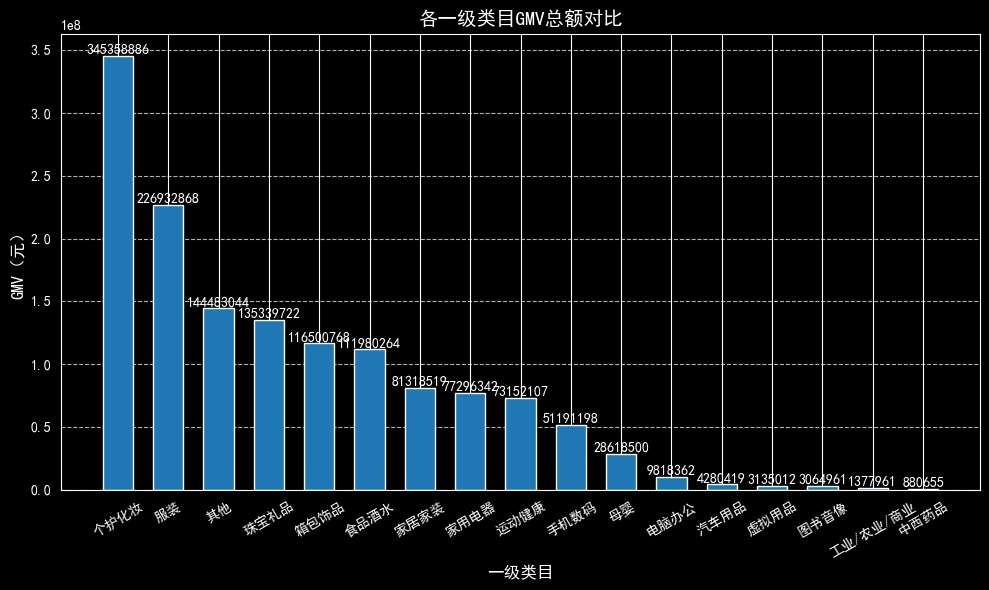

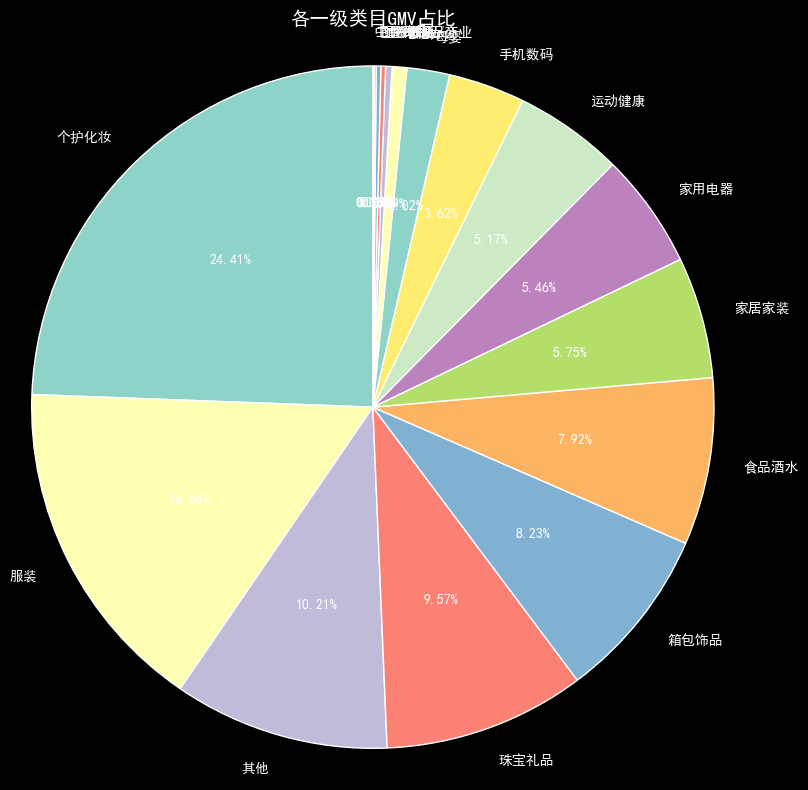

In [61]:
gmv_result = df.groupby("一级类目")["GMV"].sum().reset_index()
gmv_result = gmv_result.sort_values(by="GMV", ascending=False)

# 打印统计结果
print("===== 按一级类目GMV统计结果 =====")
print(gmv_result)

#可视化：GMV对比柱状图
plt.figure(figsize=(10, 6))  # 设置画布大小
bars = plt.bar(gmv_result["一级类目"], gmv_result["GMV"], color="#1f77b4", width=0.6)

# 给柱子添加数值标签
for bar in bars:
    height = bar.get_height()
    # 数值格式化：大额取整，小额保留1位小数
    label_text = f"{int(height)}" if height > 1000 else f"{height:.1f}"
    plt.text(bar.get_x() + bar.get_width()/2, height + 500,
             label_text, ha="center", va="bottom", fontsize=10)

# 图表美化
plt.title("各一级类目GMV总额对比", fontsize=14, fontweight="bold")
plt.xlabel("一级类目", fontsize=12)
plt.ylabel("GMV（元）", fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.7)  # 添加横向网格线
plt.tight_layout()
plt.show()

# 可视化：GMV占比饼图
plt.figure(figsize=(8, 8))
plt.pie(gmv_result["GMV"],
        labels=gmv_result["一级类目"],
        autopct="%1.2f%%",  # 显示百分比
        startangle=90,
        textprops={"fontsize": 10})
plt.title("各一级类目GMV占比", fontsize=14, fontweight="bold")
plt.axis("equal")
plt.tight_layout()
plt.show()

===== 二级类目GMV统计结果 =====
   二级类目           GMV
6  面部护肤  2.423478e+08
2    彩妆  6.840697e+07
7    香水  1.189945e+07
5  身体护理  7.196595e+06
3  洗发护发  6.008343e+06
1  女士护理  5.800028e+06
0  口腔护理  3.601912e+06
4  男士护理  9.777045e+04


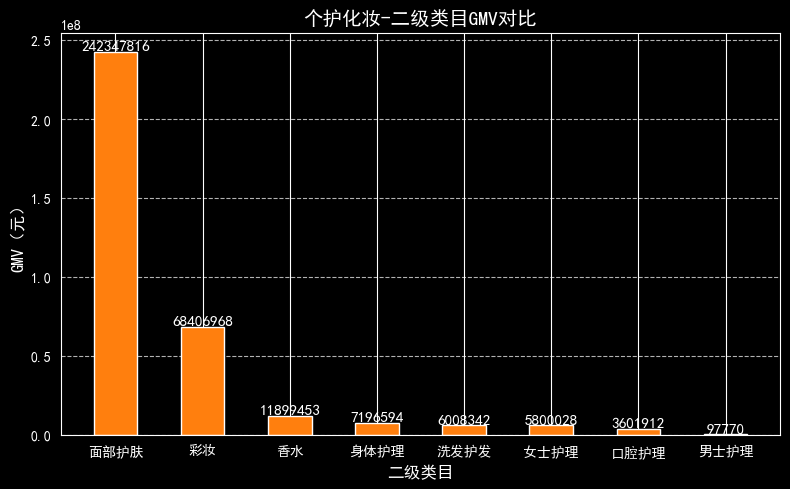

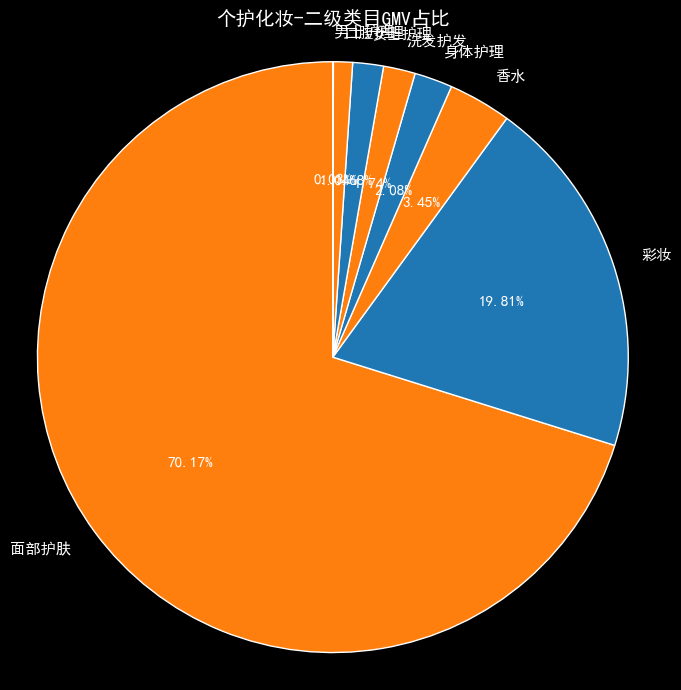

In [62]:
df_filter = df[(df['一级类目'] == '个护化妆')]

# 按二级类目分组统计GMV总和，降序排序
gmv_result = df_filter.groupby("二级类目")["GMV"].sum().reset_index()
gmv_result = gmv_result.sort_values(by="GMV", ascending=False)

# 打印统计结果，核对数据
print("===== 二级类目GMV统计结果 =====")
print(gmv_result)

#可视化：GMV对比柱状图
plt.figure(figsize=(8, 5))
bars = plt.bar(gmv_result["二级类目"], gmv_result["GMV"], color="#ff7f0e", width=0.5)

# 给柱子添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1000,
             f"{int(height)}", ha="center", va="bottom", fontsize=11)

# 图表美化
plt.title("个护化妆-二级类目GMV对比", fontsize=14, fontweight="bold")
plt.xlabel("二级类目", fontsize=12)
plt.ylabel("GMV（元）", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# 可视化：GMV占比饼图
plt.figure(figsize=(7, 7))
plt.pie(gmv_result["GMV"],
        labels=gmv_result["二级类目"],
        autopct="%1.2f%%",
        startangle=90,
        textprops={"fontsize": 11},
        colors=["#ff7f0e", "#1f77b4"])
plt.title("个护化妆-二级类目GMV占比", fontsize=14, fontweight="bold")
plt.axis("equal")
plt.tight_layout()
plt.show()

===== 二级类目GMV统计结果 =====
   二级类目           GMV
1    女装  1.185042e+08
4    男装  7.365088e+07
2    女鞋  1.304800e+07
0  女士内衣  1.303341e+07
5    男鞋  7.938748e+06
3  男士内衣  7.576371e+05


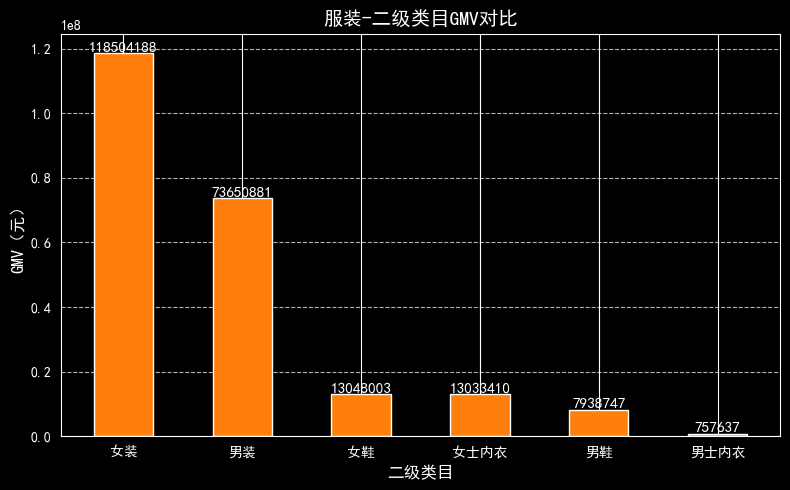

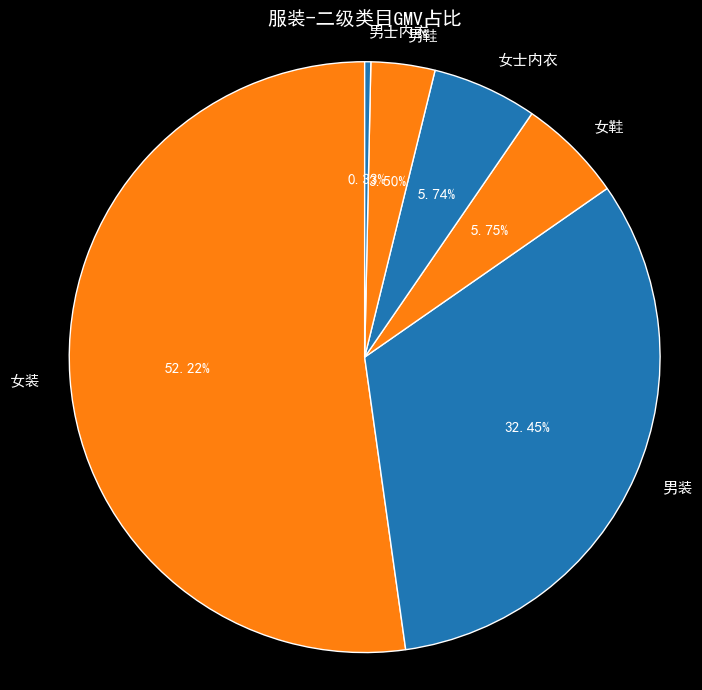

In [63]:
df_filter = df[(df['一级类目'] == '服装')]

# 按二级类目分组统计GMV总和，降序排序
gmv_result = df_filter.groupby("二级类目")["GMV"].sum().reset_index()
gmv_result = gmv_result.sort_values(by="GMV", ascending=False)

# 打印统计结果，核对数据
print("===== 二级类目GMV统计结果 =====")
print(gmv_result)

# 可视化：GMV对比柱状图
plt.figure(figsize=(8, 5))
bars = plt.bar(gmv_result["二级类目"], gmv_result["GMV"], color="#ff7f0e", width=0.5)

# 给柱子添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1000,
             f"{int(height)}", ha="center", va="bottom", fontsize=11)

# 图表美化
plt.title("服装-二级类目GMV对比", fontsize=14, fontweight="bold")
plt.xlabel("二级类目", fontsize=12)
plt.ylabel("GMV（元）", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# 可视化：GMV占比饼图
plt.figure(figsize=(7, 7))
plt.pie(gmv_result["GMV"],
        labels=gmv_result["二级类目"],
        autopct="%1.2f%%",
        startangle=90,
        textprops={"fontsize": 11},
        colors=["#ff7f0e", "#1f77b4"])
plt.title("服装-二级类目GMV占比", fontsize=14, fontweight="bold")
plt.axis("equal")
plt.tight_layout()
plt.show()

===== 三级类目GMV统计结果 =====
      三级类目           GMV
4     护肤套装  1.025082e+08
8       面膜  5.243139e+07
9     面部精华  3.532295e+07
1     乳液面霜  1.483840e+07
7     眼部护理  1.297980e+07
6      爽肤水  1.280767e+07
5       洁面  5.907781e+06
2  其他-面部护肤  4.186135e+06
3     唇部护理  1.318168e+06
0     T区护理  4.735861e+04


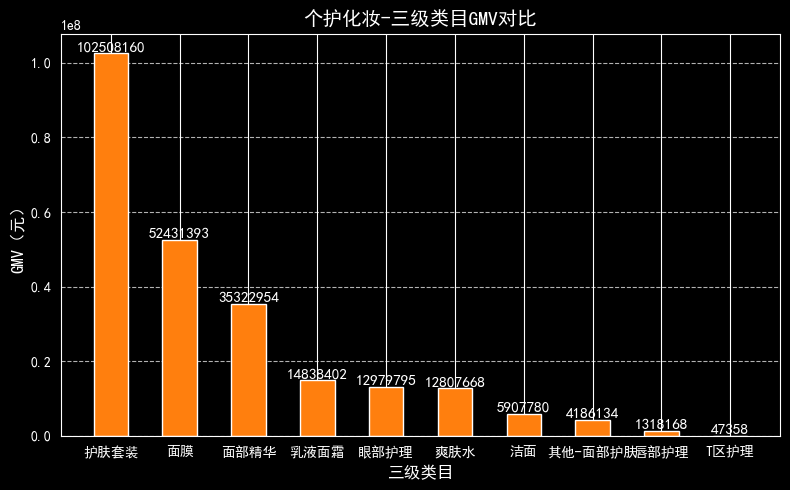

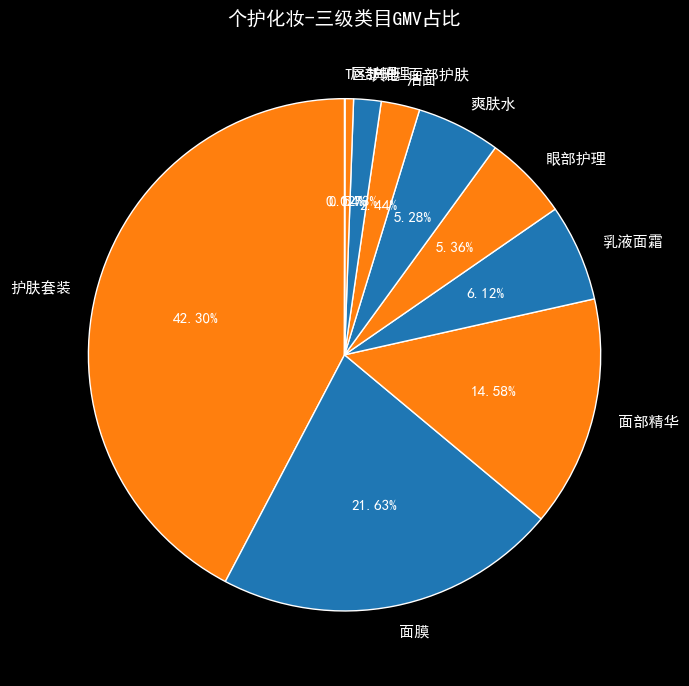

In [64]:
df_filter = df[(df['二级类目'] == '面部护肤')]

# 按三级类目分组统计GMV总和，降序排序
gmv_result = df_filter.groupby("三级类目")["GMV"].sum().reset_index()
gmv_result = gmv_result.sort_values(by="GMV", ascending=False)

# 打印统计结果，核对数据
print("===== 三级类目GMV统计结果 =====")
print(gmv_result)

# 可视化：GMV对比柱状图
plt.figure(figsize=(8, 5))
bars = plt.bar(gmv_result["三级类目"], gmv_result["GMV"], color="#ff7f0e", width=0.5)

# 给柱子添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1000,
             f"{int(height)}", ha="center", va="bottom", fontsize=11)

# 图表美化
plt.title("个护化妆-三级类目GMV对比", fontsize=14, fontweight="bold")
plt.xlabel("三级类目", fontsize=12)
plt.ylabel("GMV（元）", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# 可视化：GMV占比饼图
plt.figure(figsize=(7, 7))
plt.pie(gmv_result["GMV"],
        labels=gmv_result["三级类目"],
        autopct="%1.2f%%",
        startangle=90,
        textprops={"fontsize": 11},
        colors=["#ff7f0e", "#1f77b4"])
plt.title("个护化妆-三级类目GMV占比", fontsize=14, fontweight="bold")
plt.axis("equal")
plt.tight_layout()
plt.show()

===== 三级类目GMV统计结果 =====
      三级类目           GMV
24   女士连衣裙  3.128900e+07
19   女士羽绒服  1.812512e+07
9     女士大衣  1.125249e+07
25   女士针织衫  7.679147e+06
3     女士其他  5.747421e+06
2    女士休闲裤  5.262310e+06
0    女士T恤衫  5.221448e+06
21    女士衬衫  5.150065e+06
5    女士半身裙  4.729163e+06
6   女士卫衣帽衫  4.304985e+06
7     女士外套  3.425109e+06
22    女士西装  3.244205e+06
27    女士风衣  3.205129e+06
13   女士牛仔裤  2.948759e+06
11   女士打底裤  1.339019e+06
17  女士礼服旗袍  8.634199e+05
28    女士马甲  8.526469e+05
14    女士皮草  7.463064e+05
16    女士短裤  6.862039e+05
12    女士棉衣  6.043256e+05
8    女士大码装  5.682466e+05
20    女士背心  3.820616e+05
26   女士雪纺衫  2.995731e+05
18   女士羊绒衫  1.990585e+05
10   女士打底衫  1.835449e+05
1   女士中老年装  1.146684e+05
15    女士皮衣  5.886456e+04
4    女士加绒裤  1.239114e+04
23   女士西装裤  9.506333e+03


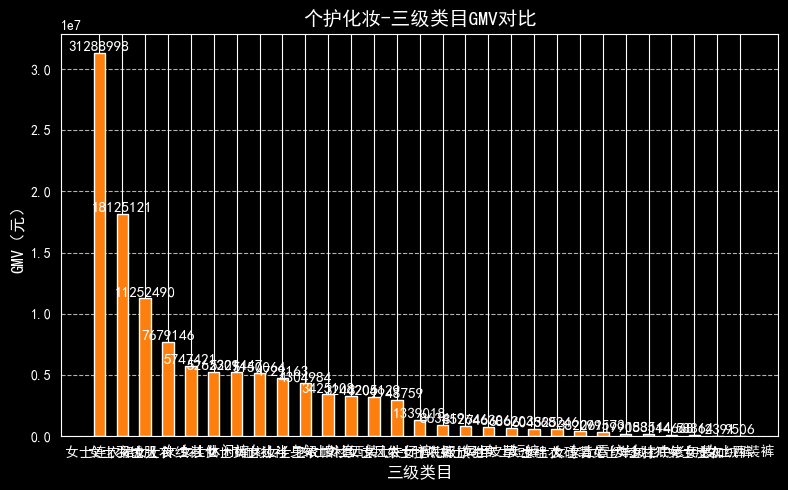

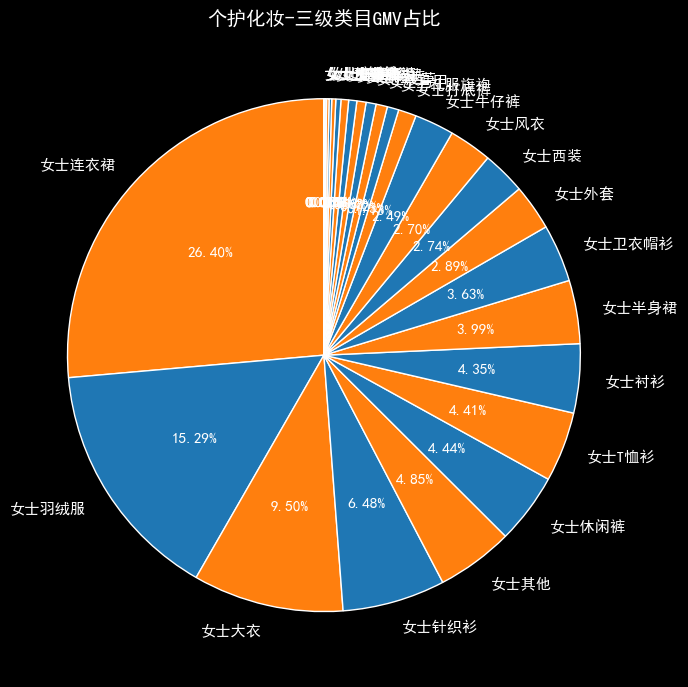

In [65]:
df_filter = df[(df['二级类目'] == '女装')]

# 按三级类目分组统计GMV总和，降序排序
gmv_result = df_filter.groupby("三级类目")["GMV"].sum().reset_index()
gmv_result = gmv_result.sort_values(by="GMV", ascending=False)

# 打印统计结果，核对数据
print("===== 三级类目GMV统计结果 =====")
print(gmv_result)

# 可视化：GMV对比柱状图
plt.figure(figsize=(8, 5))
bars = plt.bar(gmv_result["三级类目"], gmv_result["GMV"], color="#ff7f0e", width=0.5)

# 给柱子添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1000,
             f"{int(height)}", ha="center", va="bottom", fontsize=11)

# 图表美化
plt.title("个护化妆-三级类目GMV对比", fontsize=14, fontweight="bold")
plt.xlabel("三级类目", fontsize=12)
plt.ylabel("GMV（元）", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# 可视化：GMV占比饼图
plt.figure(figsize=(7, 7))
plt.pie(gmv_result["GMV"],
        labels=gmv_result["三级类目"],
        autopct="%1.2f%%",
        startangle=90,
        textprops={"fontsize": 11},
        colors=["#ff7f0e", "#1f77b4"])
plt.title("个护化妆-三级类目GMV占比", fontsize=14, fontweight="bold")
plt.axis("equal")
plt.tight_layout()
plt.show()

===== 品牌GMV统计结果 =====
                    品牌           GMV
282               秋水伊人  1.496188e+06
82             v·grass  1.125300e+06
156   奥丽嘉朵 (OBBLIGATO)  1.121141e+06
24           Five Plus  1.104170e+06
271  玛丝菲尔 (Marisfrolg)  1.093422e+06
..                 ...           ...
92                久饰女皇  3.480000e+01
148                太吾哥  2.990000e+01
168               婴格朗迪  1.990000e+01
251  汤姆猫 (TALKING TOM)  1.490000e+01
86                  上格  1.779996e+00

[371 rows x 2 columns]


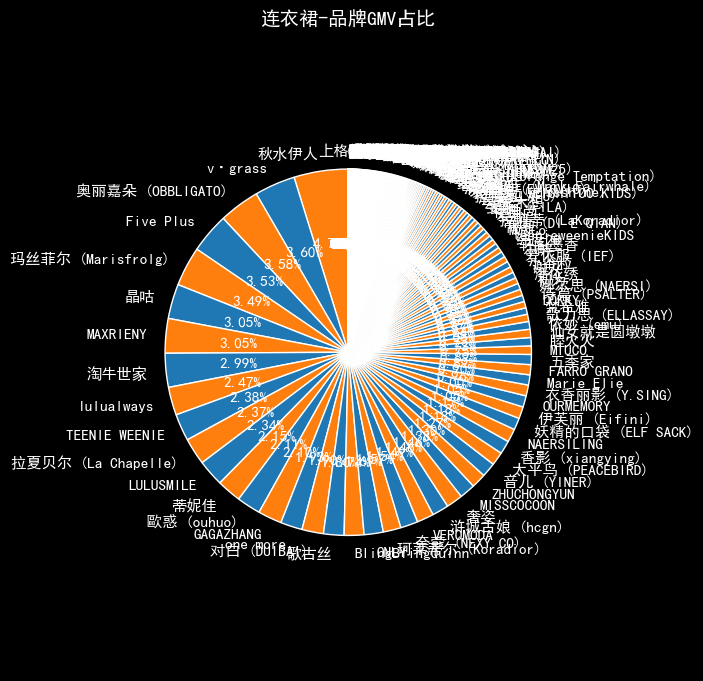

In [67]:
df_filter = df[(df['三级类目'] == '女士连衣裙')]

# 按品牌分组统计GMV总和，降序排序
gmv_result = df_filter.groupby("品牌")["GMV"].sum().reset_index()
gmv_result = gmv_result.sort_values(by="GMV", ascending=False)

# 打印统计结果，核对数据
print("===== 品牌GMV统计结果 =====")
print(gmv_result)

# 可视化：GMV占比饼图（看类目贡献度）
plt.figure(figsize=(7, 7))
plt.pie(gmv_result["GMV"],
        labels=gmv_result["品牌"],
        autopct="%1.2f%%",
        startangle=90,
        textprops={"fontsize": 11},
        colors=["#ff7f0e", "#1f77b4"])
plt.title("连衣裙-品牌GMV占比", fontsize=14, fontweight="bold")
plt.axis("equal")  # 保证饼图是正圆形
plt.tight_layout()
plt.show()

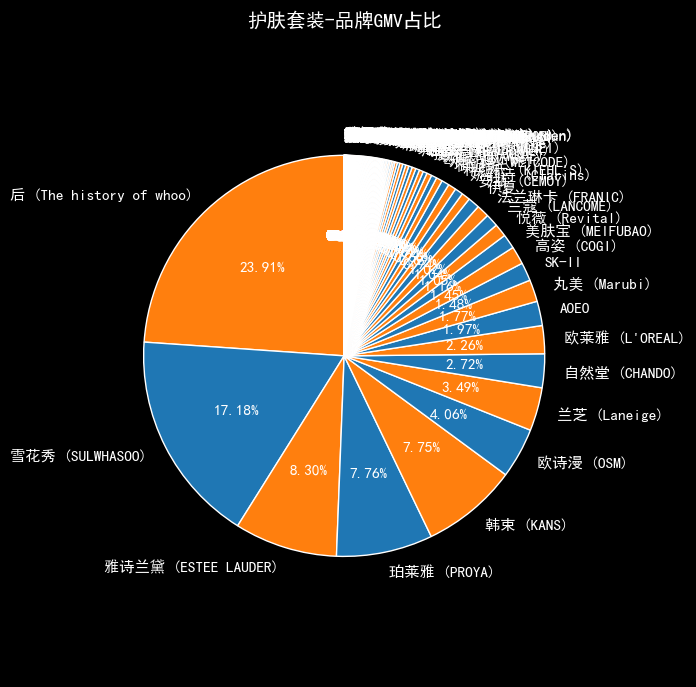

In [68]:
df_filter = df[(df['三级类目'] == '护肤套装')]

gmv_result = df_filter.groupby("品牌")["GMV"].sum().reset_index()
gmv_result = gmv_result.sort_values(by="GMV", ascending=False)

plt.figure(figsize=(7, 7))
plt.pie(gmv_result["GMV"],
        labels=gmv_result["品牌"],
        autopct="%1.2f%%",
        startangle=90,
        textprops={"fontsize": 11},
        colors=["#ff7f0e", "#1f77b4"])
plt.title("护肤套装-品牌GMV占比", fontsize=14, fontweight="bold")
plt.axis("equal") 
plt.tight_layout()
plt.show()

现存核心经营问题
（一）大盘结构风险：抗风险能力极弱，增长无抓手
1,GMV 过度依赖 2 个头部类目，一旦出现头部品牌流失、竞品低价冲击、政策监管、季节性波动等问题，全平台大盘会出现大幅震荡；
2.腰部千万级类目无明确的增长扶持策略，流量与资源过度向头部倾斜，无法形成「头部稳盘、腰部增长、尾部验证」的良性循环；
3.尾部低效类目无 ROI 核算机制，大量运营、流量资源投入到低产出类目，资源浪费严重。
（二）个护化妆类目：结构失衡，增长天花板明显
1.品类结构风险：70% GMV 集中于面部护肤，单品类波动直接影响整个类目大盘；男士护理、身体护理等潜力品类完全空白，增量空间未挖掘；
2.品牌依赖风险：护肤套装超 60% GMV 来自 5 个头部品牌，平台议价权弱，一旦头部品牌终止合作、转移渠道，类目 GMV 会出现断崖式下滑；
3.长尾价值浪费：大量长尾品牌、细分品类无流量、无运营动作，既无法分担头部风险，也无法挖掘细分用户需求。
（三）服装类目：运营效率低，潜力未释放
1.季节性风险：女装超 50% GMV 来自连衣裙、羽绒服、大衣等强季节性品类，淡季无替代品类承接流量，大盘波动大；
2.运营效率低：连衣裙品牌极度分散，无标杆品牌 / 爆品，无法形成类目心智，用户转化率、复购率提升困难；
3.品类失衡严重：男装 GMV 仅为女装的 62%，增长潜力未释放；鞋履、内衣等配套品类贡献极低，无法与女装形成场景化联动，用户客单价与生命周期价值未挖掘。
（四）整体经营管理问题
1.无明确的类目分层运营体系，资源分配全凭经验，马太效应严重，好的类目资源过剩，差的类目无资源翻身；
2.跨类目联动不足，个护化妆与服装两大头部类目无场景化绑定，流量无法在平台内高效流转，用户单次购买客单价低；
3.无全链路数据监控预警机制，仅看 GMV 结果，无流量、转化率、客单价、复购率等过程指标监控，无法提前预警类目下滑风险。


一. 头部类目稳盘：风险管控 + 交叉提效
个护化妆爆品 / 品牌风险管控：
1.拆解面部护肤 Top10 品牌、Top20 单品的 GMV 结构，对占比超 10% 的头部爆品，同步储备同赛道替补款，给与搜索加权、详情页关联推荐扶持，避免单一爆品 / 品牌下滑影响大盘；
2.与 Top5 护肤品牌签订年度框架合作，锁定平台专属权益、独家款，降低品牌流失风险。
服装季节性风险提前布局：
1.针对羽绒服、大衣等冬季品类，提前启动反季清仓活动，承接淡季流量；同时布局 T 恤、防晒衣、休闲裤等夏季刚需品类，给与流量扶持，填补淡季 GMV 缺口。
跨类目场景化联动，提升客单价：
上线「春日焕新」跨类目专属活动，搭建「穿搭 + 护肤」场景专区：
1.女装下单页 / 详情页推荐同风格彩妆、身体护理产品；
2.个护化妆页面推荐搭配服装、配饰；
设置「跨类目满 299 减 50、满 499 减 100」专属券，目标提升用户客单价 15% 以上。
二.资源优化：关停低效类目，倾斜潜力类目
1.对 10 个尾部类目做 ROI 核算，对「中西药品、工业 / 农业 / 商业」等长期低产出、无战略价值的类目，直接收缩运营或关停，把腾出来的流量、人力资源 100% 倾斜给珠宝礼品、箱包饰品、食品酒水 3 个 A 级腰部类目。
2.给腰部类目启动「千万 GMV 冲刺计划」：每周 1 次品类专属秒杀活动、首页 banner 曝光、搜索关键词加权，目标 30 天内单类目 GMV 提升 20% 以上。